## 0. Setup

This notebook supports both:

- **Google Colab with GPU**
- **Local CPU laptops**

On CPU, use a smaller subset of the dataset and fewer epochs. 

In [1]:
import os
import time
import random
import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.10.0
Torchvision version: 0.25.0


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IS_GPU = device.type == "cuda"

CONFIG = {
    "image_size": 224,
    "patch_size": 16,
    "num_classes": 10,
    "batch_size": 32 if IS_GPU else 8,
    "num_workers": 0,
    "train_subset": 3000 if IS_GPU else 600,
    "test_subset": 1000 if IS_GPU else 300,
    # "epochs": 3 if IS_GPU else 1,
    "epochs": 3,
    "lr": 1e-3,
}
CONFIG

Using device: cpu


{'image_size': 224,
 'patch_size': 16,
 'num_classes': 10,
 'batch_size': 8,
 'num_workers': 0,
 'train_subset': 600,
 'test_subset': 300,
 'epochs': 3,
 'lr': 0.001}

## 1. Dataset: CIFAR-10 resized to 224×224

CIFAR-10 images are originally **32×32**, but ImageNet-pretrained ViT and ResNet models expect around **224×224** input images.

So we resize CIFAR-10 images to 224×224 and normalize them using ImageNet statistics.

In [3]:
# On garde ImageNet car ton modèle est probablement pré-entraîné (ViT ou ResNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Configuration des transformations
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

root = '/Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab6/data/' 
train_full = datasets.CIFAR10(root=root, train=True, download=False, transform=train_transform)
test_full = datasets.CIFAR10(root=root, train=False, download=False, transform=test_transform)

class_names = train_full.classes
print(f"Classes détectées : {class_names}")

/Users/amine_rb/miniconda3/envs/n2v/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes détectées : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# Use a subset to keep the lab fas :) 
train_indices = list(range(CONFIG["train_subset"]))
test_indices = list(range(CONFIG["test_subset"]))

train_ds = Subset(train_full, train_indices)
test_ds = Subset(test_full, test_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))
print("Classes:", class_names)

Train samples: 600
Test samples: 300
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


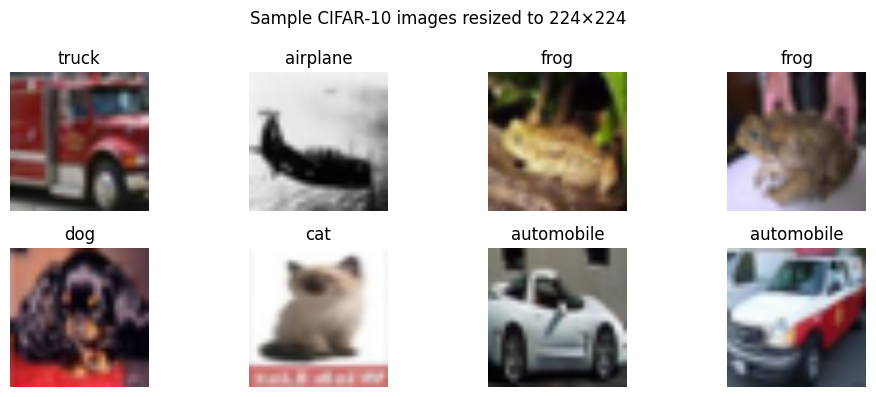

In [5]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo ImageNet normalization for visualization."""
    img = img_tensor.clone().detach().cpu()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    return img.clamp(0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 images resized to 224×224")
plt.tight_layout()
plt.show()

# Part A : Build ViT input components manually

Before using a pretrained ViT, we manually build the input pipeline:

1. Image → patches
2. Patches → flattened vectors
3. Flattened vectors → embeddings
4. Add positional embeddings
5. Add `[CLS]` token

## 2. Step 1 : Split image into patches

For ViT-B/16:

- image size = 224×224
- patch size = 16×16
- number of patches per side = 224 / 16 = 14
- total patches = 14 × 14 = 196

Each patch becomes one token.

Image shape: torch.Size([3, 224, 224])
Label: truck


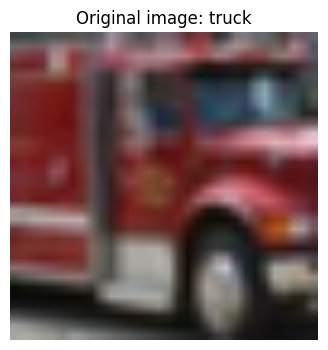

In [6]:
# Pick one image for visualization.
sample_img = images[0]  # shape: [3, 224, 224]
sample_label = labels[0].item()
print("Image shape:", sample_img.shape)
print("Label:", class_names[sample_label])

plt.figure(figsize=(4, 4))
plt.imshow(denormalize(sample_img).permute(1, 2, 0))
plt.title(f"Original image: {class_names[sample_label]}")
plt.axis("off")
plt.show()

In [7]:
def image_to_patches(img, patch_size=16):
    """
    Convert one image tensor [C, H, W] into patches.

    Expected output shape:
        [num_patches, C, patch_size, patch_size]
    """
    C, H, W = img.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch size."

    # 1. Définition de l'unfold avec stride = patch_size pour ne pas avoir de chevauchement
    unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
    
    # 2. Ajout de la dimension batch [1, C, H, W] car unfold l'exige
    # Résultat : [1, C * patch_size * patch_size, num_patches]
    patches = unfold(img.unsqueeze(0))
    
    # 3. On enlève la dimension batch et on transpose pour avoir les patchs en première dimension
    # [C * p * p, num_patches] -> [num_patches, C * p * p]
    patches = patches.squeeze(0).transpose(0, 1)
    
    # 4. On redimensionne pour retrouver la structure [num_patches, C, patch_size, patch_size]
    patches = patches.view(-1, C, patch_size, patch_size)
    
    return patches


In [8]:
# Test your implementation.
patches = image_to_patches(sample_img, CONFIG["patch_size"])

# TODO 2:
# Print the shape of patches.
# Expected: [196, 3, 16, 16]
print("Patches shape:", patches.shape)


Patches shape: torch.Size([196, 3, 16, 16])


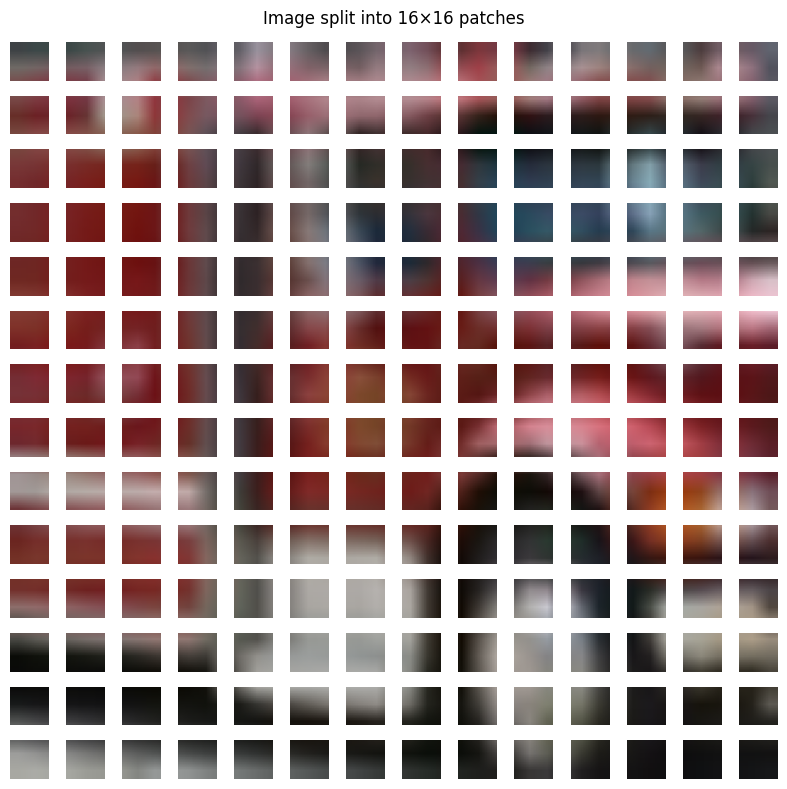

In [9]:
def show_patch_grid(patches, grid_size=14, max_patches=196):
    """Visualize patches in their original grid order."""
    plt.figure(figsize=(8, 8))
    for i in range(min(max_patches, patches.shape[0])):
        plt.subplot(grid_size, grid_size, i + 1)
        patch = denormalize(patches[i]).permute(1, 2, 0)
        plt.imshow(patch)
        plt.axis("off")
    plt.suptitle("Image split into 16×16 patches")
    plt.tight_layout()
    plt.show()

show_patch_grid(patches, grid_size=CONFIG["image_size"] // CONFIG["patch_size"])

### Checkpoint question

If we change the patch size from 16×16 to 32×32 while keeping the image size 224×224:

1. How many patches do we get? 49 (224/32 = 7 patches per side -> 7×7 = 49 total)
2. What happens to computation cost? It decreases, fewer patches means a shorter token sequence, and self-attention scales as O(n²), so going from 196 to 49 tokens cuts the attention cost by ~16×.
3. What happens to spatial detail? It decreases. Each patch covers a larger image region (32×32 vs 16×16), so fine-grained local features are harder to capture

## 3. Step 2.1 : Patch → Embedding

A transformer cannot process image patches directly. It expects vectors.

For each patch:

1. Flatten it into a vector.
2. Apply a linear projection to map it into an embedding dimension.

For RGB 16×16 patches:

\[
16 x 16 x 3 = 768
\]

So each flattened patch has 768 values.

In [10]:
patch_size = CONFIG["patch_size"]
patch_dim = 3 * patch_size * patch_size
embed_dim = 768

print("Patch dimension:", patch_dim)
print("Embedding dimension:", embed_dim)

Patch dimension: 768
Embedding dimension: 768


In [11]:
def flatten_patches(patches):
    """
    Input:
        patches: [num_patches, C, P, P]
    Output:
        flat_patches: [num_patches, C*P*P]
    """
    # TODO 3:
    # Flatten each patch into a 1D vector.
    flat_patches = patches.flatten(1)
    return flat_patches

flat_patches = flatten_patches(patches)
print("Flattened patches shape:", flat_patches.shape)

# a small check 
assert flat_patches.shape == (196, 768)

Flattened patches shape: torch.Size([196, 768])


In [12]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_dim, embed_dim):
        super().__init__()
        # TODO 4:
        # Define a linear layer that maps patch_dim -> embed_dim.
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, flat_patches):
        # TODO 5:
        # Apply the projection to flat_patches.
        embeddings = self.proj(flat_patches)
        return embeddings

patch_embedder = PatchEmbedding(patch_dim, embed_dim)
patch_embeddings = patch_embedder(flat_patches)
print("Patch embeddings shape:", patch_embeddings.shape)

# a small check
assert patch_embeddings.shape == (196, 768)

Patch embeddings shape: torch.Size([196, 768])


### Checkpoint question

What is the difference between:

- **the flattened patch vector**: each patch [C, P, P] is simply reshaped into a 1D vector of size C×P×P (here 3×16×16 = 768). No learning involved, it just stacks all pixel values in sequence.
- **the patch embedding vector**: the result of applying a learned linear layer to the flattened patch. The model projects the raw pixel vector into an embedding space, producing a more expressive and trainable representation.

Why do we need the linear projection?

The transformer expects a fixed embedding dimension that may differ from C×P×P. More importantly, a raw pixel vector is not a great input, the linear projection is learned during training and lets the model extract meaningful features from pixel values rather than processing them directly.

## 4. Step 2.2 : Positional embeddings

Transformers process tokens as a sequence. Without positional information, the model does not know where each patch came from.

So we add a learned position vector to each patch embedding:

\[
x_i = e_i + p_i
\]

where:

- \(e_i\) = patch embedding
- \(p_i\) = positional embedding
- \(x_i\) = final input token for patch \(i\)

In [13]:
num_patches = (CONFIG["image_size"] // CONFIG["patch_size"]) ** 2
print("Number of patches:", num_patches)

class AddPositionEmbedding(nn.Module):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        # TODO 6:
        # Create learnable positional embeddings of shape [1, num_patches, embed_dim].
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, embed_dim) * 0.02)

    def forward(self, patch_embeddings):
        """
        patch_embeddings shape can be:
            [num_patches, embed_dim] or [batch, num_patches, embed_dim]
        """
        if patch_embeddings.dim() == 2:
            patch_embeddings = patch_embeddings.unsqueeze(0)

        # TODO 7:
        # Add pos embeddings to patch embeddings.
        x = patch_embeddings + self.pos_embed
        return x

pos_layer = AddPositionEmbedding(num_patches, embed_dim)
x_with_pos = pos_layer(patch_embeddings)
print("With position shape:", x_with_pos.shape)

# a check
assert x_with_pos.shape == (1, 196, 768)

Number of patches: 196
With position shape: torch.Size([1, 196, 768])


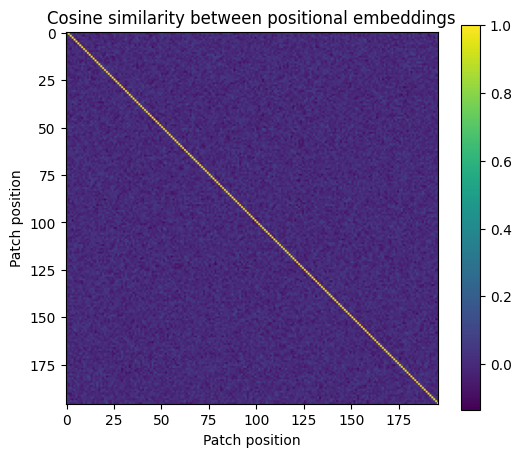

In [14]:
# Visualization: cosine similarity between positional embeddings.
# This shows how positions are represented before training (random initially).
with torch.no_grad():
    P = pos_layer.pos_embed.squeeze(0)  # [num_patches, embed_dim]
    P_norm = P / (P.norm(dim=1, keepdim=True) + 1e-8)
    sim = P_norm @ P_norm.T

plt.figure(figsize=(6, 5))
plt.imshow(sim.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Cosine similarity between positional embeddings")
plt.xlabel("Patch position")
plt.ylabel("Patch position")
plt.show()


## 5. Step 2.3 : Add the `[CLS]` token

After patch embedding and positional embedding, we have many token vectors:

\[
x_1, x_2, ..., x_n
\]

But for image classification, we need **one vector** to represent the whole image.

So ViT adds a special learnable token at the beginning:

\[
[CLS], x_1, x_2, ..., x_n
\]

The `[CLS]` token interacts with all patch tokens through attention. After the encoder, the final `[CLS]` vector is used for classification.

In [15]:
class AddCLSToken(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        # TODO 8:
        # Create a learnable CLS token of shape [1, 1, embed_dim].
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

    def forward(self, x):
        """
        x: [batch, num_patches, embed_dim]
        output: [batch, num_patches + 1, embed_dim]
        """
        B = x.shape[0]

        # TODO 9:
        # Expand CLS token to batch size and concatenate it before patch tokens.
        cls_tokens = self.cls_token.expand(B, -1, -1)
        out = torch.cat((cls_tokens, x), dim=1)
        return out

cls_layer = AddCLSToken(embed_dim)
x_final = cls_layer(x_with_pos)
print("Final ViT input sequence shape:", x_final.shape)

# a check 
assert x_final.shape == (1, 197, 768)

Final ViT input sequence shape: torch.Size([1, 197, 768])


### Checkpoint question

Why do we use one `[CLS]` token instead of one `[CLS]` token per patch?

One CLS token is enough because it attends to every patch token through self-attention at each layer. By the final encoder layer it has aggregated global context from the whole image. Plus that adding a CLS token per patch would be redundant, each patch token already carries its own local information and we only need a single vector to feed into the classification head.

# Part B : Load pretrained models

Now that we understand the input pipeline, we use pretrained models.

We will compare:

- **ViT-B/16**: transformer-based model
- **ResNet-18**: CNN-based model

For transfer learning, we freeze the backbone and train only the final classification layer.

## 6. Load pretrained ViT and inspect its structure

We use torchvision's pretrained ViT-B/16.

This model was pretrained on ImageNet. It expects:

- image size: 224×224
- patch size: 16×16
- patch tokens: 196
- plus one `[CLS]` token: 197 tokens total

In [16]:
# Load pretrained ViT-B/16.
# The first time this runs, it downloads weights.
vit_weights = models.ViT_B_16_Weights.IMAGENET1K_V1
vit = models.vit_b_16(weights=vit_weights)
vit.eval()
vit = vit.to(device)

print(vit)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [17]:
# Inspect  shapes
print("Patch projection layer:", vit.conv_proj)
print("Hidden dimension:", vit.hidden_dim)
print("Number of encoder layers:", len(vit.encoder.layers))
print("Classification head:", vit.heads)

Patch projection layer: Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
Hidden dimension: 768
Number of encoder layers: 12
Classification head: Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)


## 7. Extract tokens before and after the ViT encoder

We will inspect:

- token embeddings before the encoder
- token representations after the encoder
- the `[CLS]` vector

In [18]:
@torch.no_grad()
def get_vit_tokens(model, batch_images):
    """
    Return tokens before and after the encoder for torchvision ViT.

    batch_images: [B, 3, 224, 224]
    """
    model.eval()
    x = batch_images.to(device)

    # Patchify through conv projection.
    x = model.conv_proj(x)  # [B, hidden_dim, 14, 14]

    # Flatten spatial dimensions into sequence.
    x = x.flatten(2).transpose(1, 2)  # [B, 196, hidden_dim]

    # Add CLS token.
    B = x.shape[0]
    cls_token = model.class_token.expand(B, -1, -1)
    x = torch.cat([cls_token, x], dim=1)  # [B, 197, hidden_dim]

    tokens_before_encoder = x.clone()

    # Encoder includes positional embedding internally in torchvision.
    tokens_after_encoder = model.encoder(x)

    return tokens_before_encoder, tokens_after_encoder

small_batch = images[:4].to(device)
before_tokens, after_tokens = get_vit_tokens(vit, small_batch)

print("Before encoder:", before_tokens.shape)
print("After encoder:", after_tokens.shape)
print("CLS after encoder:", after_tokens[:, 0, :].shape)

Before encoder: torch.Size([4, 197, 768])
After encoder: torch.Size([4, 197, 768])
CLS after encoder: torch.Size([4, 768])


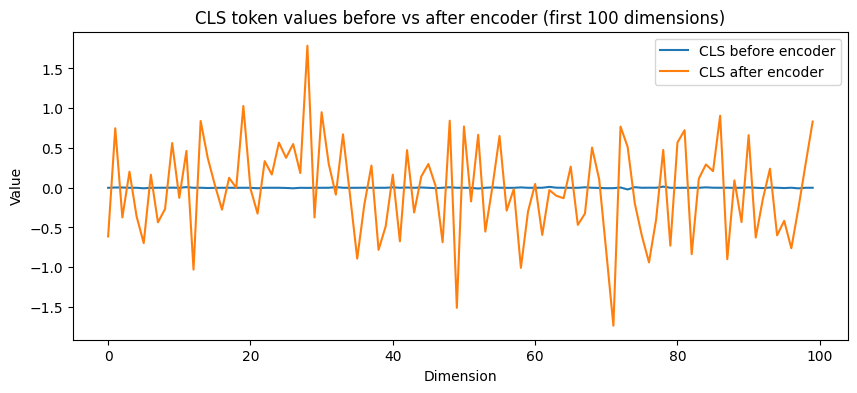

In [19]:
# Plot CLS vector before and after encoder for the same image.
idx = 0
cls_before = before_tokens[idx, 0].detach().cpu()
cls_after = after_tokens[idx, 0].detach().cpu()

plt.figure(figsize=(10, 4))
plt.plot(cls_before[:100], label="CLS before encoder")
plt.plot(cls_after[:100], label="CLS after encoder")
plt.title("CLS token values before vs after encoder (first 100 dimensions)")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.legend()
plt.show()

In [20]:
# TODO 10:
# Compute and print the L2 norm of CLS before and after the encoder.

cls_before_norm = torch.linalg.norm(cls_before)
cls_after_norm = torch.linalg.norm(cls_after)

print("CLS norm before:", cls_before_norm)
print("CLS norm after:", cls_after_norm)

CLS norm before: tensor(0.4451)
CLS norm after: tensor(15.7817)


# Part C : Transfer learning: ViT vs ResNet

We now adapt pretrained models to CIFAR-10.

Strategy:

1. Load pretrained model.
2. Freeze all backbone parameters.
3. Replace the final classifier head with a new layer for 10 classes.
4. Train only the new classifier head. (feature extraction from the previous lecture 😉)


## 8. Helper functions for training and evaluation

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    return running_loss / total, correct / total, all_preds, all_labels


def fit_model(model, train_loader, test_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    start = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, test acc={test_acc:.4f}")

    elapsed = time.time() - start
    return history, elapsed

## 9. Build transfer-learning ResNet-18

ResNet-18 is a CNN. Its final classifier is called `fc`.

In [22]:
def build_resnet18_transfer(num_classes=10, freeze_backbone=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    if freeze_backbone:
        # TODO 11:
        # Freeze all model parameters.
        for p in model.parameters():
            p.requires_grad = False

    in_features = model.fc.in_features

    # TODO 12:
    # Replace model.fc with a the Linear layer 
    model.fc = nn.Linear(in_features, num_classes)

    return model

resnet_model = build_resnet18_transfer(CONFIG["num_classes"], freeze_backbone=True).to(device)
print(resnet_model.fc)
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Linear(in_features=512, out_features=10, bias=True)
Trainable parameters: 5130


## 10. Build transfer-learning ViT-B/16

In torchvision ViT, the final classifier is stored inside `model.heads`.

In [23]:
def build_vit_transfer(num_classes=10, freeze_backbone=True):
    weights = models.ViT_B_16_Weights.IMAGENET1K_V1
    model = models.vit_b_16(weights=weights)

    if freeze_backbone:
        # TODO 13:
        # Freeze all model parameters.
        for p in model.parameters():
            p.requires_grad = False

    in_features = model.heads.head.in_features

    # TODO 14:
    # Replace model.heads.head with the new Linear layer 
    model.heads.head = nn.Linear(in_features, num_classes)

    return model

vit_model = build_vit_transfer(CONFIG["num_classes"], freeze_backbone=True).to(device)
print(vit_model.heads)
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Sequential(
  (head): Linear(in_features=768, out_features=10, bias=True)
)
Trainable parameters: 7690


## 11. Train ResNet-18 head

In [24]:
resnet_history, resnet_time = fit_model(
    resnet_model,
    train_loader,
    test_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    device=device,
)
print(f"ResNet training time: {resnet_time:.1f} seconds")


Epoch 1/3


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

train loss=2.0837, train acc=0.2717, test acc=0.4933
Epoch 2/3


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

train loss=1.5350, train acc=0.5117, test acc=0.6000
Epoch 3/3


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

train loss=1.2682, train acc=0.6367, test acc=0.5933
ResNet training time: 88.3 seconds


## 12. Train ViT head

ViT-B/16 is heavier than ResNet-18. On CPU, this can be slow. If no gpu used, use a subset of the data!!

In [25]:
vit_history, vit_time = fit_model(
    vit_model,
    train_loader,
    test_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    device=device,
)
print(f"ViT training time: {vit_time:.1f} seconds")


Epoch 1/3


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

train loss=0.9641, train acc=0.7883, test acc=0.9133
Epoch 2/3


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

train loss=0.2603, train acc=0.9600, test acc=0.9133
Epoch 3/3


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

train loss=0.1625, train acc=0.9750, test acc=0.9133
ViT training time: 674.6 seconds


## 13. Compare training curves

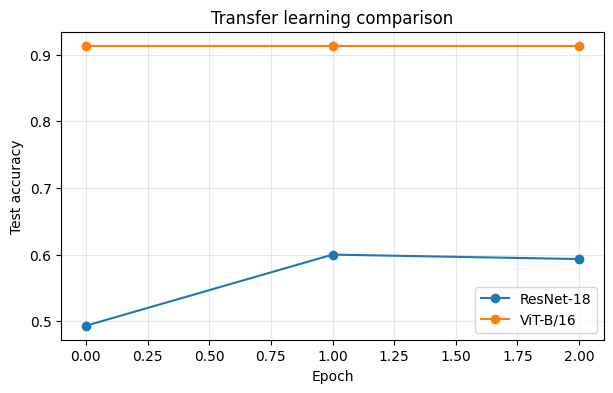

In [26]:
# Plot test accuracies for both models on the same chart.
plt.figure(figsize=(7, 4))
plt.plot(resnet_history["test_acc"], marker="o", label="ResNet-18")
plt.plot(vit_history["test_acc"], marker="o", label="ViT-B/16")
plt.title("Transfer learning comparison")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [27]:
print("ResNet final test accuracy:", resnet_history["test_acc"][-1])
print("ViT final test accuracy:", vit_history["test_acc"][-1])
print("ResNet training time:", resnet_time)
print("ViT training time:", vit_time)

ResNet final test accuracy: 0.5933333333333334
ViT final test accuracy: 0.9133333333333333
ResNet training time: 88.25114607810974
ViT training time: 674.6055459976196


## 14. Confusion matrix

Use this to inspect which classes are confused by each model.

  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

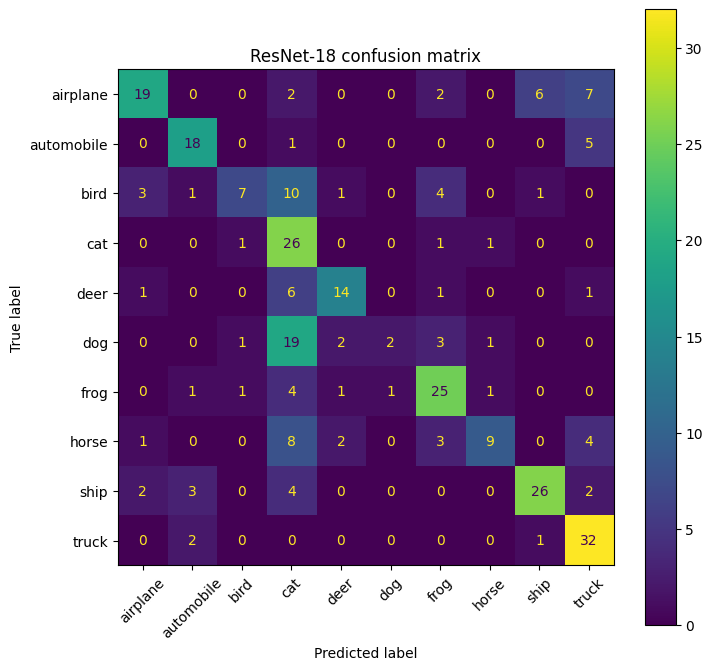

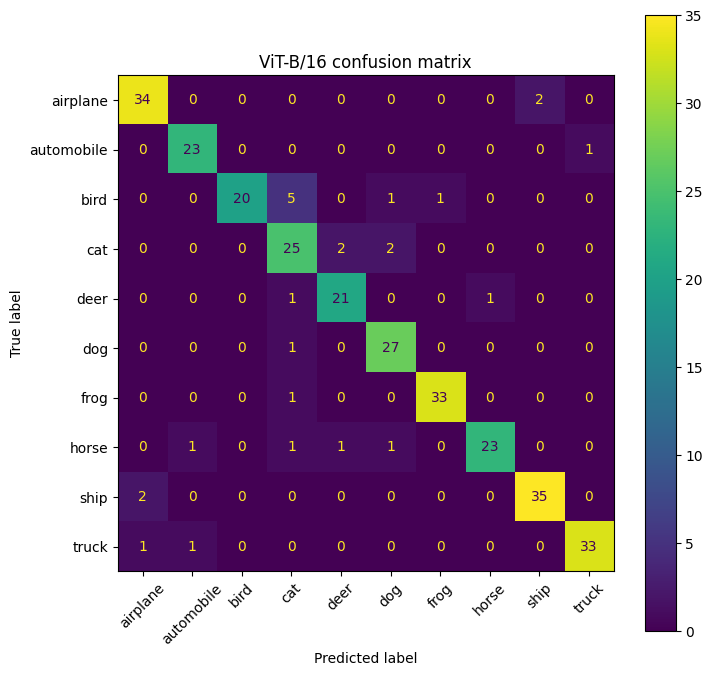

In [28]:
criterion = nn.CrossEntropyLoss()
_, _, resnet_preds, resnet_labels = evaluate(resnet_model, test_loader, criterion, device)
_, _, vit_preds, vit_labels = evaluate(vit_model, test_loader, criterion, device)

cm = confusion_matrix(resnet_labels, resnet_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ResNet-18 confusion matrix")
plt.show()

cm = confusion_matrix(vit_labels, vit_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ViT-B/16 confusion matrix")
plt.show()

# Final discussion questions

Answer briefly:

1. **Why is transfer learning useful here?** The pretrained backbone already learned general visual features (edges, textures, shapes) from ImageNet. Fine-tuning only the head on a small CIFAR-10 subset gives good accuracy without needing a lot of data or training time.

2. **Which model trained faster: ResNet or ViT? Why?** ResNet was much faster (~88s vs ~675s). ViT processes 197 tokens through 12 attention layers, and self-attention is quadratic in sequence length, making each forward pass significantly more expensive than ResNet's convolutions.

3. **If you had a very small dataset, would you prefer CNN or ViT? Explain.** Without pretraining, CNN .. it has strong inductive biases (locality, translation invariance) that make it easier to train with few samples. ViT has none of these priors and typically needs far more data to learn spatial structure from scratch. That said, if we use pretrained weights as done here, ViT can still generalize well even with limited data.